In [1]:
# 1. Imports and Setup
# =============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
import cv2
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

✅ Using device: cuda


In [3]:
# =============================================================
# Imports
# =============================================================
import os
import random
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from sklearn.model_selection import StratifiedShuffleSplit

# =============================================================
# Config
# =============================================================
base_dir = "/kaggle/input/datasets/maitygouranga/brest-cancer-datasets/monuseg/Brest cancer/TNBC_without_split"

img_dir  = os.path.join(base_dir, "Images")
mask_dir = os.path.join(base_dir, "Masks")

IMG_SIZE   = 256
BATCH_SIZE = 4
SEED       = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# =============================================================
# Dataset Class
# =============================================================
class MosMedDataset(Dataset):
    def __init__(self, img_dir, mask_dir, indices=None, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.images = sorted(os.listdir(img_dir))
        self.masks  = sorted(os.listdir(mask_dir))

        if indices is not None:
            self.images = [self.images[i] for i in indices]
            self.masks  = [self.masks[i] for i in indices]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path  = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = np.array(
            Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        ) / 255.0

        mask = np.array(
            Image.open(mask_path).convert("L").resize((IMG_SIZE, IMG_SIZE))
        ) / 255.0

        mask = (mask > 0.5).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask  = augmented["mask"]

        image = torch.tensor(image).permute(2, 0, 1).float()
        mask  = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

# =============================================================
# Augmentations
# =============================================================
train_transform = A.Compose([
    A.Resize(256,256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=15,
        p=0.5
    ),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
])

test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
])

# =============================================================
# Stratified Split for Segmentation (70 Train / 20 Test / 10 Val)
# =============================================================

def compute_foreground_ratio(mask_path):
    mask = np.array(Image.open(mask_path).convert("L")) / 255.0
    return np.mean(mask > 0.5)

all_images = sorted(os.listdir(img_dir))
all_masks  = sorted(os.listdir(mask_dir))

foreground_ratios = []
for m in all_masks:
    fg = compute_foreground_ratio(os.path.join(mask_dir, m))
    foreground_ratios.append(fg)

foreground_ratios = np.array(foreground_ratios)

# ---- Create strata bins
strata = np.digitize(
    foreground_ratios,
    bins=[0.001, 0.01, 0.05]
)

indices = np.arange(len(all_images))

# =============================================================
# Step 1: Stratified Train (70%) vs Temp (30%)
# =============================================================
sss1 = StratifiedShuffleSplit(
    n_splits=1, test_size=0.3, random_state=SEED
)
train_idx, temp_idx = next(sss1.split(indices, strata))

# =============================================================
# Step 2: Random Temp → Test (20%) / Val (10%)
# =============================================================
np.random.seed(SEED)
np.random.shuffle(temp_idx)

n_test = int(0.2 * len(indices))   # 20%
test_idx = temp_idx[:n_test]
val_idx  = temp_idx[n_test:]       # remaining 10%
# =============================================================
# Datasets & Loaders
# =============================================================
train_dataset = MosMedDataset(
    img_dir, mask_dir, indices=train_idx, transform=train_transform
)
val_dataset = MosMedDataset(
    img_dir, mask_dir, indices=val_idx, transform=val_transform
)
test_dataset = MosMedDataset(
    img_dir, mask_dir, indices=test_idx, transform=test_transform
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

# =============================================================
# Sanity Check
# =============================================================
def avg_fg(idx):
    return np.mean(foreground_ratios[idx])

print("✅ Stratified Dataset Loaded Successfully!")
print(f"Total Images : {len(all_images)}")
print(f"Train        : {len(train_dataset)} | Avg FG: {avg_fg(train_idx):.4f}")
print(f"Validation   : {len(val_dataset)}   | Avg FG: {avg_fg(val_idx):.4f}")
print(f"Test         : {len(test_dataset)}  | Avg FG: {avg_fg(test_idx):.4f}")

✅ Stratified Dataset Loaded Successfully!
Total Images : 50
Train        : 35 | Avg FG: 0.1202
Validation   : 5   | Avg FG: 0.0605
Test         : 10  | Avg FG: 0.1728


In [4]:
from torchinfo import summary
import torch
import torch.nn as nn
import torch.nn.functional as F


# =============================================================
# 🔷 GATED CHOQUET FUSION (Improved)
# =============================================================
class GatedChoquetFusion(nn.Module):
    def __init__(self, ch):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Conv2d(ch * 2, ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, inputs):
        x1, x2 = inputs

        stacked = torch.stack([x1, x2], dim=0)
        sorted_vals, _ = torch.sort(stacked, dim=0)

        g = self.gate(torch.cat([x1, x2], dim=1))
        g1, g2 = g[:, 0:1], g[:, 1:2]

        return g1 * sorted_vals[0] + g2 * sorted_vals[1]


# =============================================================
# 🔷 EDGE ENHANCER
# =============================================================
class EdgeEnhancer(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv = nn.Conv2d(ch, ch, 3, padding=1)

    def forward(self, x):
        edge = x - F.avg_pool2d(x, 3, stride=1, padding=1)
        return x + self.conv(edge)


# =============================================================
# 🔷 CROSS ATTENTION
# =============================================================
class CrossAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.q = nn.Conv2d(ch, ch, 1)
        self.k = nn.Conv2d(ch, ch, 1)
        self.v = nn.Conv2d(ch, ch, 1)

    def forward(self, dec, enc):
        q = self.q(dec)
        k = self.k(enc)
        v = self.v(enc)

        attn = torch.softmax(q * k, dim=1)
        return dec + attn * v


# =============================================================
# 🔷 CHANNEL ATTENTION (CAM)
# =============================================================
class CAM(nn.Module):
    def __init__(self, ch, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(ch, ch // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch // reduction, ch, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.fc(self.pool(x))


# =============================================================
# 🔷 SPATIAL ATTENTION (SAM)
# =============================================================
class SAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, 7, padding=3)

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        maxv, _ = torch.max(x, dim=1, keepdim=True)
        return x * torch.sigmoid(self.conv(torch.cat([avg, maxv], dim=1)))


# =============================================================
# 🔥 SIMPLE CONV BLOCK (REPLACES DACC)
# =============================================================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

        self.cam = CAM(out_ch)
        self.sam = SAM()

    def forward(self, x):
        x = self.block(x)
        x = self.cam(x)
        x = self.sam(x)
        return x


# =============================================================
# 🔥 FINAL U-NET (NO DACC)
# =============================================================
class UNetSegmentation(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()

        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.e1 = ConvBlock(in_ch, 64)
        self.e2 = ConvBlock(64, 128)
        self.e3 = ConvBlock(128, 256)
        self.e4 = ConvBlock(256, 512)

        # Edge Enhancers
        self.edge1 = EdgeEnhancer(64)
        self.edge2 = EdgeEnhancer(128)
        self.edge3 = EdgeEnhancer(256)
        self.edge4 = EdgeEnhancer(512)

        # Bottleneck
        self.bottleneck = ConvBlock(512, 1024)

        # Cross Attention
        self.cross4 = CrossAttention(512)
        self.cross3 = CrossAttention(256)
        self.cross2 = CrossAttention(128)
        self.cross1 = CrossAttention(64)

        # Choquet
        self.cf4 = GatedChoquetFusion(512)
        self.cf3 = GatedChoquetFusion(256)
        self.cf2 = GatedChoquetFusion(128)
        self.cf1 = GatedChoquetFusion(64)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.d4 = ConvBlock(512, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.d3 = ConvBlock(256, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.d2 = ConvBlock(128, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.d1 = ConvBlock(64, 64)

        self.final = nn.Conv2d(64, out_ch, 1)

    def forward(self, x):

        # Encoder
        e1 = self.edge1(self.e1(x))
        e2 = self.edge2(self.e2(self.pool(e1)))
        e3 = self.edge3(self.e3(self.pool(e2)))
        e4 = self.edge4(self.e4(self.pool(e3)))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.up4(b)
        d4 = self.cross4(d4, e4)
        d4 = self.cf4([d4, e4])
        d4 = self.d4(d4)

        d3 = self.up3(d4)
        d3 = self.cross3(d3, e3)
        d3 = self.cf3([d3, e3])
        d3 = self.d3(d3)

        d2 = self.up2(d3)
        d2 = self.cross2(d2, e2)
        d2 = self.cf2([d2, e2])
        d2 = self.d2(d2)

        d1 = self.up1(d2)
        d1 = self.cross1(d1, e1)
        d1 = self.cf1([d1, e1])
        d1 = self.d1(d1)

        return torch.sigmoid(self.final(d1))


# =============================================================
# TEST
# =============================================================
if __name__ == "__main__":
    model = UNetSegmentation().cuda()
    x = torch.randn(4, 3, 256, 256).cuda()
    y = model(x)

    print("Output:", y.shape)
    print("\n================= MODEL SUMMARY =================\n")
    print(summary(model, input_size=(4, 3, 256, 256)))

Output: torch.Size([4, 1, 256, 256])

================= MODEL SUMMARY =================

Layer (type:depth-idx)                   Output Shape              Param #
UNetSegmentation                         [4, 1, 256, 256]          --
├─ConvBlock: 1-1                         [4, 64, 256, 256]         --
│    └─Sequential: 2-1                   [4, 64, 256, 256]         --
│    │    └─Conv2d: 3-1                  [4, 64, 256, 256]         1,792
│    │    └─BatchNorm2d: 3-2             [4, 64, 256, 256]         128
│    │    └─ReLU: 3-3                    [4, 64, 256, 256]         --
│    │    └─Conv2d: 3-4                  [4, 64, 256, 256]         36,928
│    │    └─BatchNorm2d: 3-5             [4, 64, 256, 256]         128
│    │    └─ReLU: 3-6                    [4, 64, 256, 256]         --
│    └─CAM: 2-2                          [4, 64, 256, 256]         --
│    │    └─AdaptiveAvgPool2d: 3-7       [4, 64, 1, 1]             --
│    │    └─Sequential: 3-8              [4, 64, 1, 1]   

Epoch 1/100 [Val]: 100%|██████████| 2/2 [00:00<00:00,  3.38it/s]



Epoch 1/100
LR: 0.000100
Train Loss: 0.7525 | Val Loss: 0.7725
Train Dice: 0.2108 | Val Dice: 0.1633
Train IoU : 0.1635 | Val IoU : 0.1062
✅ Best model saved (Epoch 1, Val Loss 0.7725)


Epoch 2/100 [Val]: 100%|██████████| 2/2 [00:00<00:00,  3.63it/s]



Epoch 2/100
LR: 0.000100
Train Loss: 0.7016 | Val Loss: 0.7728
Train Dice: 0.2565 | Val Dice: 0.1640
Train IoU : 0.2578 | Val IoU : 0.1062


Epoch 3/100 [Val]: 100%|██████████| 2/2 [00:00<00:00,  3.63it/s]


...


Epoch 98/100
LR: 0.000100
Train Loss: 0.2287 | Val Loss: 0.2929
Train Dice: 0.6732 | Val Dice: 0.5616
Train IoU : 0.7626 | Val IoU : 0.6957


Epoch 99/100 [Val]: 100%|██████████| 2/2 [00:00<00:00,  3.35it/s]



Epoch 99/100
LR: 0.000100
Train Loss: 0.2336 | Val Loss: 0.2968
Train Dice: 0.6609 | Val Dice: 0.5480
Train IoU : 0.7632 | Val IoU : 0.6743


Epoch 100/100 [Val]: 100%|██████████| 2/2 [00:00<00:00,  3.36it/s]



Epoch 100/100
LR: 0.000100
Train Loss: 0.2167 | Val Loss: 0.2901
Train Dice: 0.6922 | Val Dice: 0.5844
Train IoU : 0.7784 | Val IoU : 0.6838

🎉 Training Completed!
🏆 Best Epoch: 97
✔ Best Val Loss: 0.2895


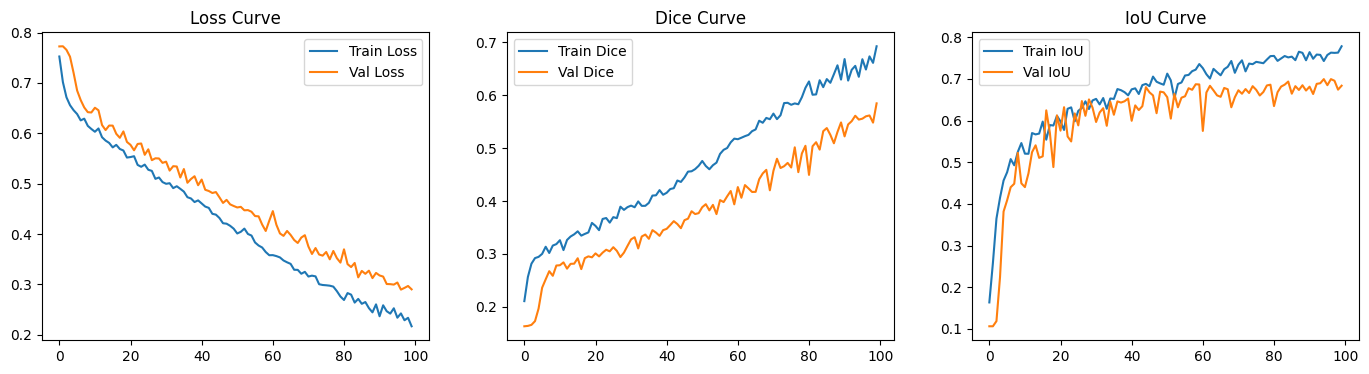

In [5]:
# LOSS + METRICS
# =============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt


# BCE + Dice Loss
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
        self.bce = nn.BCELoss()

    def forward(self, preds, targets):
        bce_loss = self.bce(preds, targets)

        preds_f = preds.view(-1)
        targets_f = targets.view(-1)
        inter = (preds_f * targets_f).sum()
        dice_loss = 1 - (2 * inter + self.smooth) / \
                        (preds_f.sum() + targets_f.sum() + self.smooth)

        return 0.5 * bce_loss + 0.5 * dice_loss


# Dice Metric
def dice_coef(y_true, y_pred, smooth=1e-5):
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    inter = (y_true_f * y_pred_f).sum()
    return (2. * inter + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)


# IoU Metric
def iou_score(preds, masks, threshold=0.5, eps=1e-6):
    preds_bin = (preds > threshold).float()
    masks_bin = (masks > threshold).float()

    inter = (preds_bin * masks_bin).sum().item()
    union = preds_bin.sum().item() + masks_bin.sum().item() - inter

    return inter / (union + eps)


# =============================================================
# TRAINING LOOP
# =============================================================
def train_model(model, train_loader, val_loader, epochs=50):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    criterion = BCEDiceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Tracking curves
    train_losses, val_losses = [], []
    train_dice_scores, val_dice_scores = [], []
    train_iou_scores, val_iou_scores = [], []

    best_val_loss = float("inf")
    best_epoch = 0
    best_model_weights = None

    for epoch in range(epochs):

        # ------------------ TRAIN ------------------
        model.train()
        train_loss = train_dice = train_iou = 0

        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # 🔥 LR Scheduler (Reduce LR on plateau)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode='min',
                patience=5,
                factor=0.5
            )

            # Accumulate
            train_loss += loss.item()
            train_dice += dice_coef(masks, preds).item()
            train_iou += iou_score(preds, masks)

        # ------------------ VALIDATION ------------------
        model.eval()
        val_loss = val_dice = val_iou = 0

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images, masks = images.to(device), masks.to(device)

                preds = model(images)
                val_loss += criterion(preds, masks).item()
                val_dice += dice_coef(masks, preds).item()
                val_iou += iou_score(preds, masks)

        # ------------------ AVERAGES ------------------
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss / len(val_loader)
        avg_train_dice = train_dice / len(train_loader)
        avg_val_dice   = val_dice / len(val_loader)
        avg_train_iou  = train_iou / len(train_loader)
        avg_val_iou    = val_iou / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_dice_scores.append(avg_train_dice)
        val_dice_scores.append(avg_val_dice)
        train_iou_scores.append(avg_train_iou)
        val_iou_scores.append(avg_val_iou)

        # 🔥 STEP LR SCHEDULER
        scheduler.step(avg_val_loss)

        # 🔥 GET CURRENT LR
        current_lr = optimizer.param_groups[0]['lr']

        # ------------------ PRINT ------------------
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"LR: {current_lr:.6f}")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"Train Dice: {avg_train_dice:.4f} | Val Dice: {avg_val_dice:.4f}")
        print(f"Train IoU : {avg_train_iou:.4f} | Val IoU : {avg_val_iou:.4f}")

        # ------------------ SAVE BEST ------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_unet_monu.pth")
            print(f"✅ Best model saved (Epoch {epoch+1}, Val Loss {best_val_loss:.4f})")

    # ------------------ LOAD BEST MODEL ------------------
    model.load_state_dict(best_model_weights)

    print("\n🎉 Training Completed!")
    print(f"🏆 Best Epoch: {best_epoch}")
    print(f"✔ Best Val Loss: {best_val_loss:.4f}")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_dice": train_dice_scores,
        "val_dice": val_dice_scores,
        "train_iou": train_iou_scores,
        "val_iou": val_iou_scores,
    }


# =============================================================
# PLOTTING FUNCTION
# =============================================================
def plot_training(history):
    plt.figure(figsize=(17, 4))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(history["train_losses"], label="Train Loss")
    plt.plot(history["val_losses"], label="Val Loss")
    plt.title("Loss Curve")
    plt.legend()

    # Dice
    plt.subplot(1, 3, 2)
    plt.plot(history["train_dice"], label="Train Dice")
    plt.plot(history["val_dice"], label="Val Dice")
    plt.title("Dice Curve")
    plt.legend()

    # IoU
    plt.subplot(1, 3, 3)
    plt.plot(history["train_iou"], label="Train IoU")
    plt.plot(history["val_iou"], label="Val IoU")
    plt.title("IoU Curve")
    plt.legend()

    plt.show()

model = UNetSegmentation().to(device)
history = train_model(model, train_loader, val_loader, epochs=100)
plot_training(history)

In [6]:
# =============================================================
# 🔥 FULL TEST EVALUATION (ALL METRICS)
# =============================================================

import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =============================================================
# BASIC METRICS
# =============================================================

def dice_coef(y_true, y_pred, smooth=1e-5):
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    intersection = (y_true_f * y_pred_f).sum()
    return (2. * intersection + smooth) / (y_true_f.sum() + y_pred_f.sum() + smooth)

def iou_coef(y_true, y_pred, smooth=1e-5):
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    intersection = (y_true_f * y_pred_f).sum()
    union = y_true_f.sum() + y_pred_f.sum() - intersection
    return (intersection + smooth) / (union + smooth)

# =============================================================
# 🔥 ADVANCED INSTANCE METRICS (PQ, DQ, SQ, AJI)
# =============================================================

def compute_pq(true, pred):
    """
    Simplified PQ computation (binary)
    """
    true = true.astype(np.uint8)
    pred = pred.astype(np.uint8)

    TP = np.sum((true == 1) & (pred == 1))
    FP = np.sum((true == 0) & (pred == 1))
    FN = np.sum((true == 1) & (pred == 0))

    if TP == 0:
        return 0, 0, 0

    dq = TP / (TP + 0.5 * FP + 0.5 * FN)
    sq = TP / (TP + FP + FN)
    pq = dq * sq

    return pq, dq, sq


def compute_aji(true, pred):
    """
    Simplified AJI (binary version)
    """
    true = true.astype(np.uint8)
    pred = pred.astype(np.uint8)

    intersection = np.sum((true == 1) & (pred == 1))
    union = np.sum((true == 1) | (pred == 1))

    if union == 0:
        return 1.0

    return intersection / union

# =============================================================
# LOAD MODEL
# =============================================================

print("📥 Loading best model...")
model.load_state_dict(torch.load("best_unet_monu.pth", map_location=device))
model.eval()

# =============================================================
# ACCUMULATORS
# =============================================================

dice_total, iou_total = 0, 0
acc_total, prec_total, rec_total, f1_total = 0, 0, 0, 0
pq_total, dq_total, sq_total, aji_total = 0, 0, 0, 0

print("🧪 Evaluating on test set...")

# =============================================================
# TEST LOOP
# =============================================================

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Evaluating Test Set"):

        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        preds_bin = (preds > 0.5).float()

        # Dice & IoU
        dice_total += dice_coef(masks, preds_bin).item()
        iou_total += iou_coef(masks, preds_bin).item()

        # Flatten for sklearn metrics
        y_true = masks.cpu().numpy().flatten()
        y_pred = preds_bin.cpu().numpy().flatten()

        acc_total += accuracy_score(y_true, y_pred)
        prec_total += precision_score(y_true, y_pred, zero_division=0)
        rec_total += recall_score(y_true, y_pred, zero_division=0)
        f1_total += f1_score(y_true, y_pred, zero_division=0)

        # Instance metrics
        pred_np = preds_bin.cpu().numpy()
        true_np = masks.cpu().numpy()

        for i in range(pred_np.shape[0]):
            pq, dq, sq = compute_pq(true_np[i, 0], pred_np[i, 0])
            aji = compute_aji(true_np[i, 0], pred_np[i, 0])

            pq_total += pq
            dq_total += dq
            sq_total += sq
            aji_total += aji

# =============================================================
# FINAL RESULTS
# =============================================================

num_batches = len(test_loader)
num_samples = len(test_dataset)

print("\n" + "="*50)
print("🎯 FULL TEST SET EVALUATION")
print("="*50)

print(f"✅ Dice:       {dice_total/num_batches:.4f}")
print(f"✅ IoU:        {iou_total/num_batches:.4f}")

print(f"✅ Accuracy:   {acc_total/num_batches:.4f}")
print(f"✅ Precision:  {prec_total/num_batches:.4f}")
print(f"✅ Recall:     {rec_total/num_batches:.4f}")
print(f"✅ F1 Score:   {f1_total/num_batches:.4f}")

print(f"✅ PQ:         {pq_total/num_samples:.4f}")
print(f"✅ DQ:         {dq_total/num_samples:.4f}")
print(f"✅ SQ:         {sq_total/num_samples:.4f}")
print(f"✅ AJI:        {aji_total/num_samples:.4f}")

print("="*50)

📥 Loading best model...
🧪 Evaluating on test set...


Evaluating Test Set: 100%|██████████| 3/3 [00:01<00:00,  2.35it/s]


🎯 FULL TEST SET EVALUATION
✅ Dice:       0.8399
✅ IoU:        0.7240
✅ Accuracy:   0.9474
✅ Precision:  0.8557
✅ Recall:     0.8260
✅ F1 Score:   0.8399
✅ PQ:         0.5980
✅ DQ:         0.8330
✅ SQ:         0.7155
✅ AJI:        0.7155


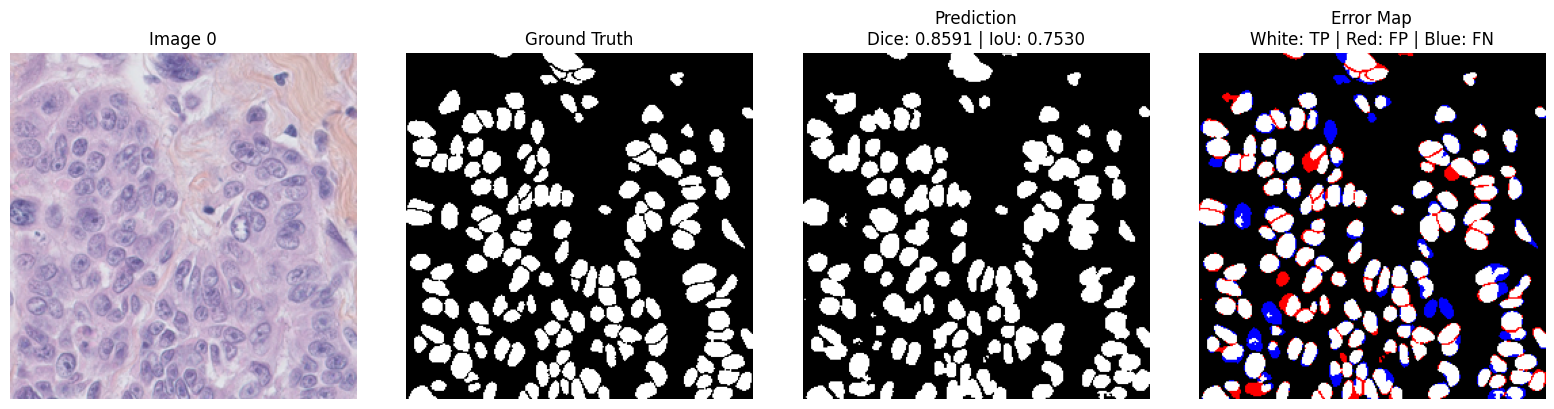

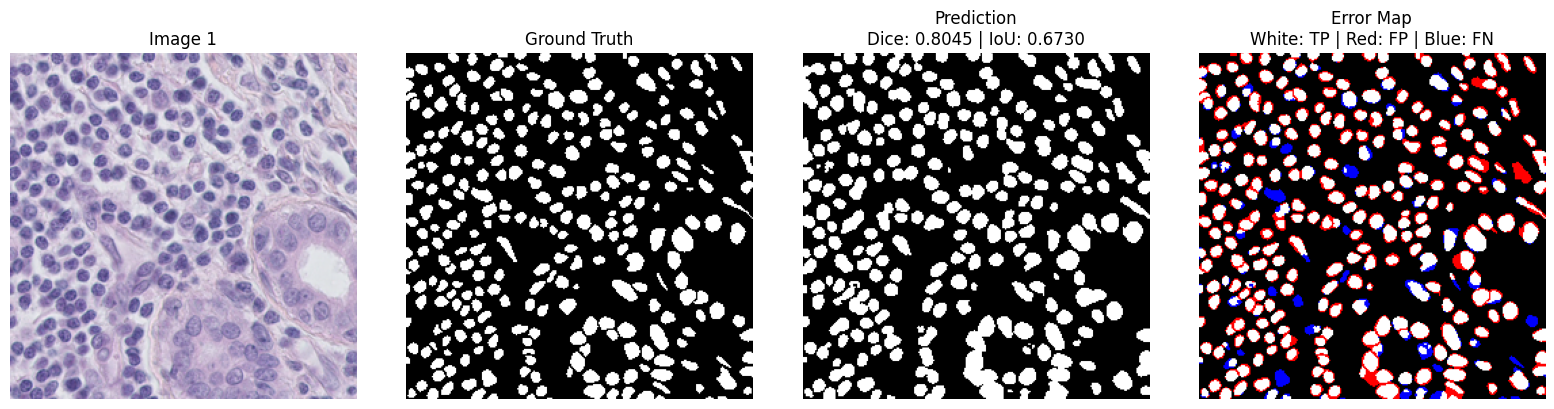

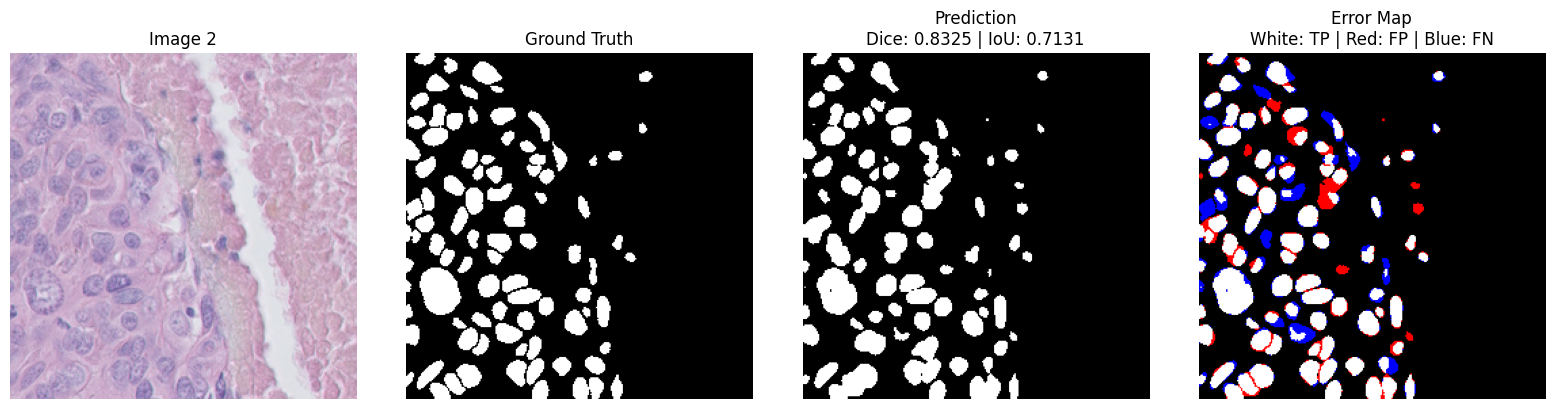

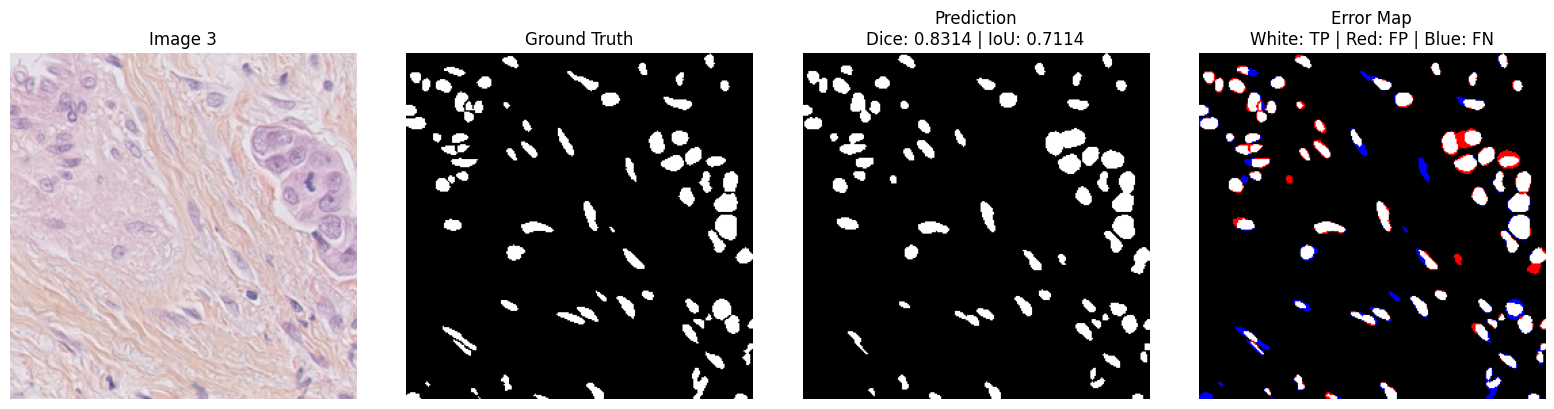

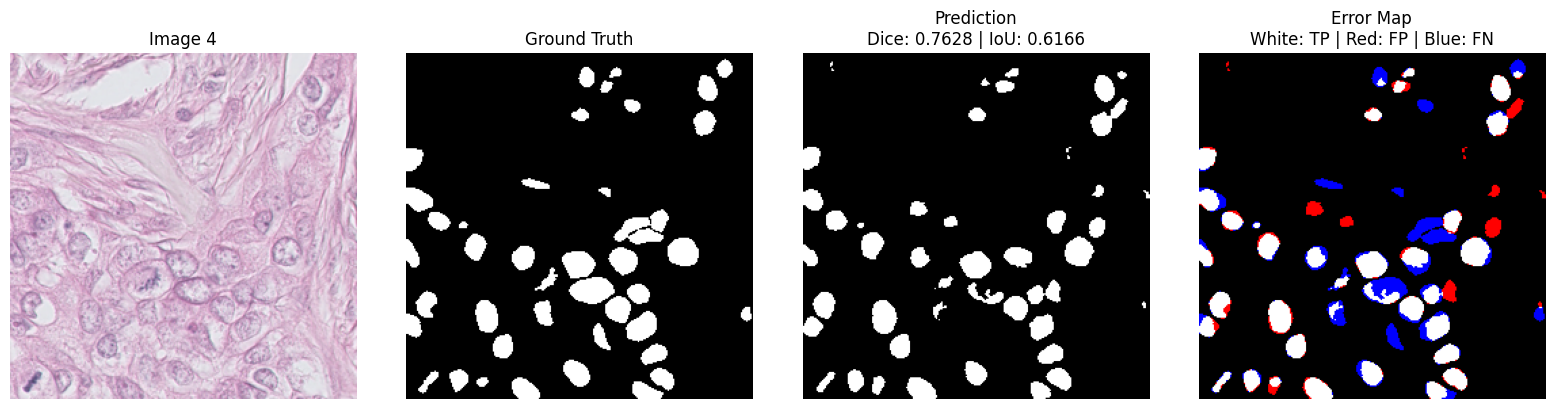

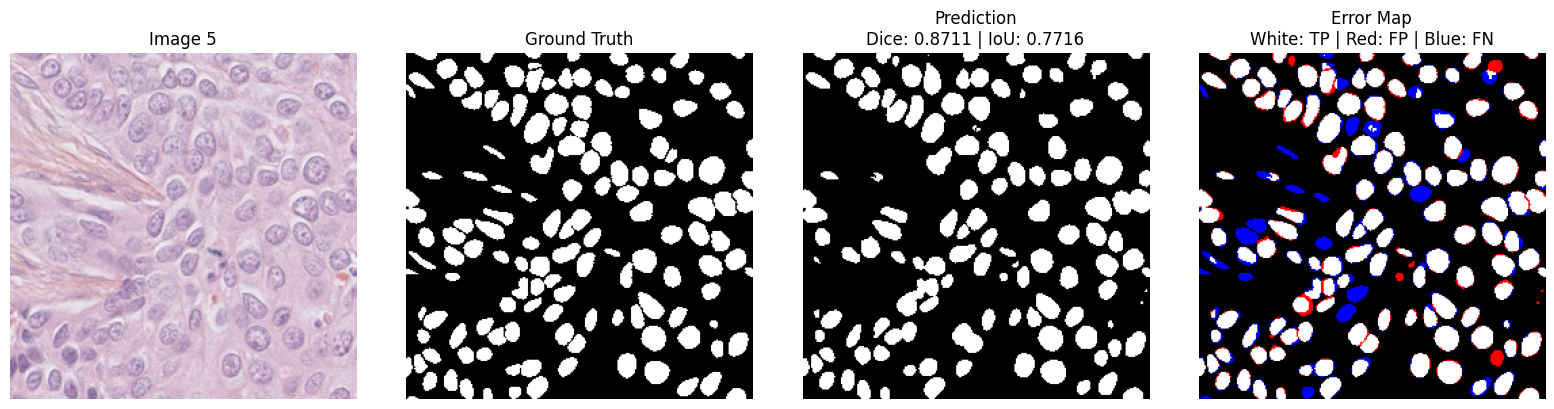

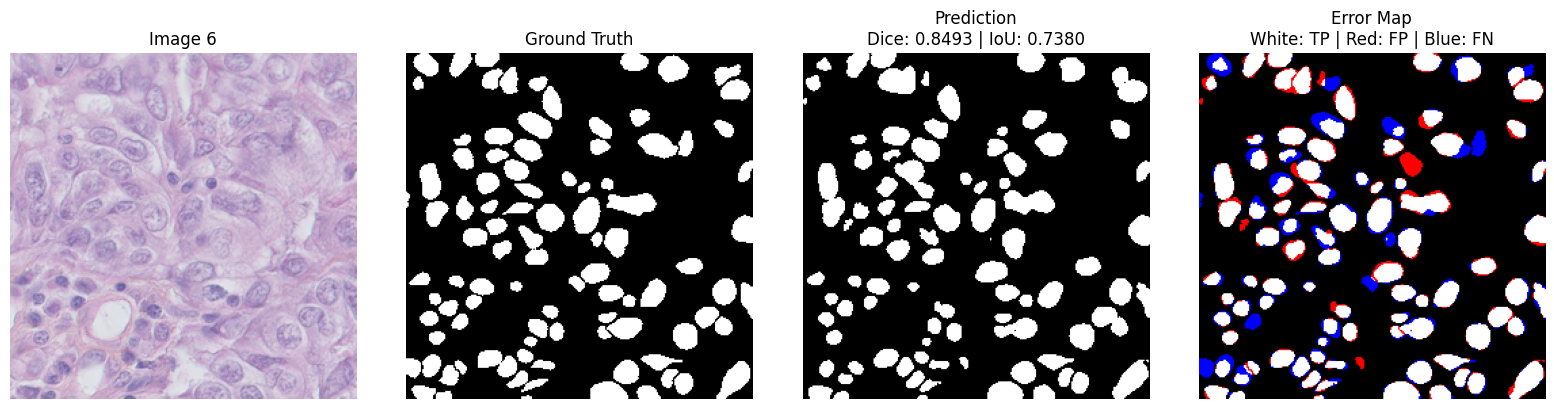

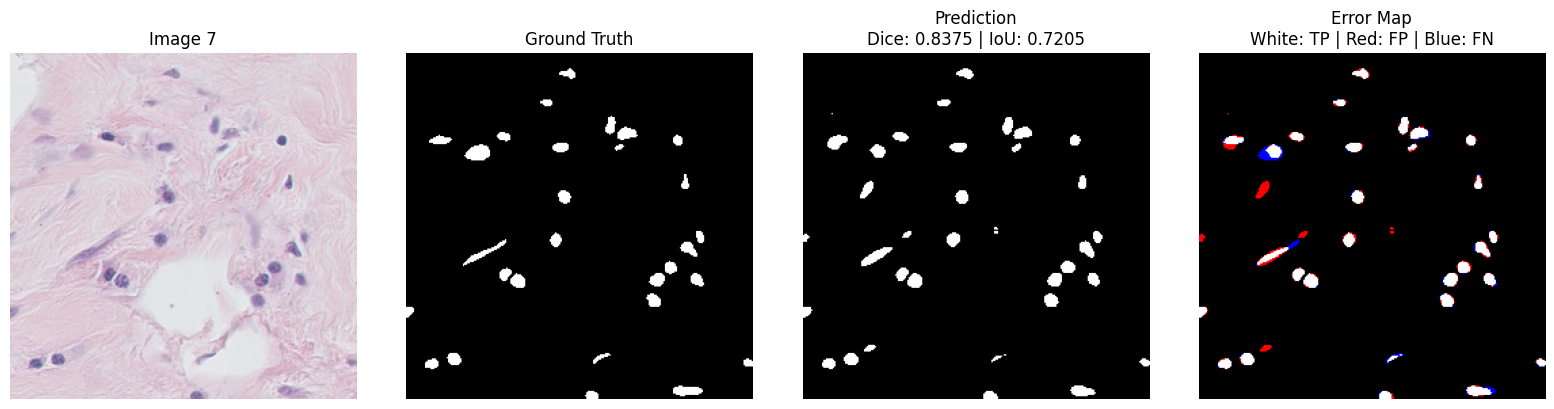

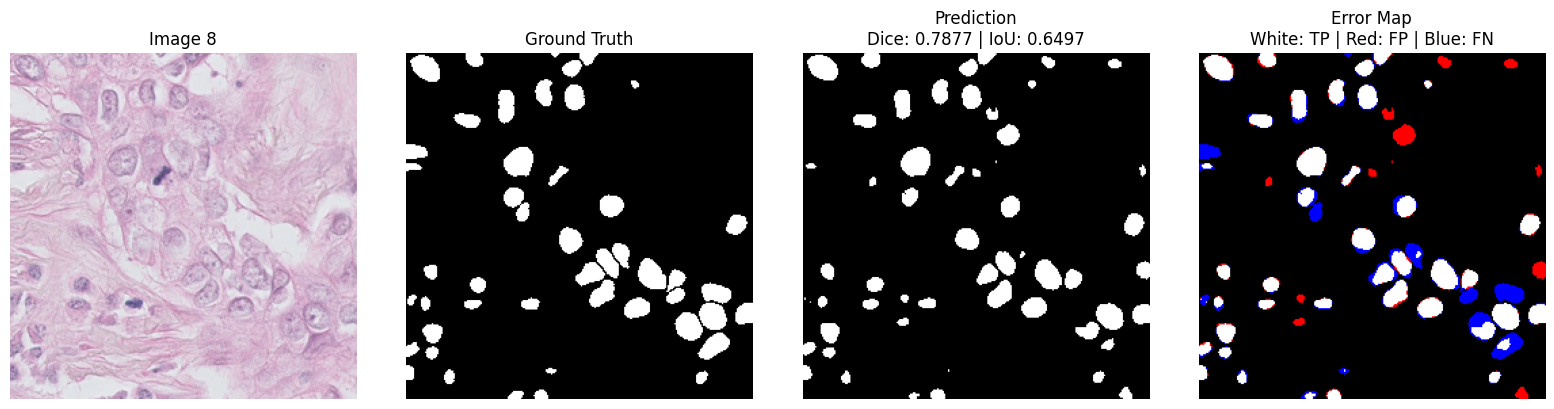

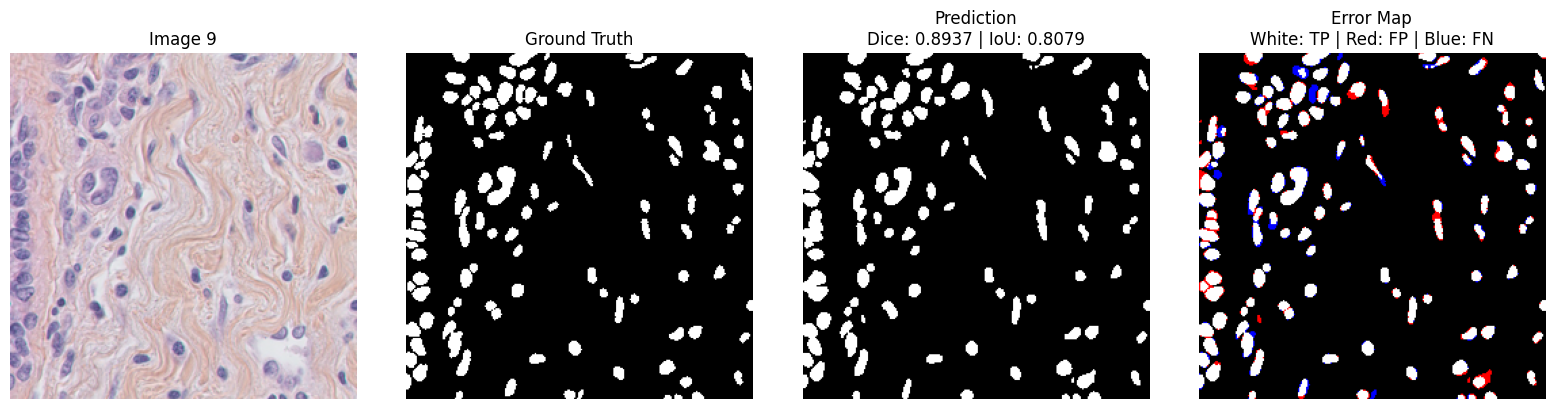

In [7]:
# =============================================================
# 🔥 FINAL VISUALIZATION (FIXED + METRICS + ERROR MAP)
# =============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# Metrics
# -------------------------------------------------------------
def dice_coef_single(y_true, y_pred, smooth=1e-5):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)

def iou_coef_single(y_true, y_pred, smooth=1e-5):
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / (union + smooth)

# -------------------------------------------------------------
# Visualization Function
# -------------------------------------------------------------
def visualize_all_test(model, dataset, threshold=0.5):

    model.eval()

    for idx in range(len(dataset)):

        image, mask = dataset[idx]

        with torch.no_grad():
            pred = model(image.unsqueeze(0).to(device))

            # 🔥 AUTO-FIX: apply sigmoid ONLY if needed
            if pred.min() < 0 or pred.max() > 1:
                pred = torch.sigmoid(pred)

            pred = pred.cpu().squeeze().numpy()

        pred_mask = (pred > threshold).astype(np.uint8)
        true_mask = mask.squeeze().numpy().astype(np.uint8)

        # -----------------------------
        # Metrics
        # -----------------------------
        dice = dice_coef_single(true_mask, pred_mask)
        iou = iou_coef_single(true_mask, pred_mask)

        # -----------------------------
        # Error Map
        # -----------------------------
        error_map = np.zeros((*true_mask.shape, 3), dtype=np.uint8)

        tp = (true_mask == 1) & (pred_mask == 1)
        fp = (true_mask == 0) & (pred_mask == 1)
        fn = (true_mask == 1) & (pred_mask == 0)

        error_map[tp] = [255, 255, 255]  # White
        error_map[fp] = [255, 0, 0]      # Red
        error_map[fn] = [0, 0, 255]      # Blue

        # -----------------------------
        # Plot
        # -----------------------------
        plt.figure(figsize=(16,4))

        # Input Image
        plt.subplot(1,4,1)
        if image.shape[0] == 3:
            plt.imshow(image.permute(1,2,0))
        else:
            plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f"Image {idx}")
        plt.axis("off")

        # Ground Truth
        plt.subplot(1,4,2)
        plt.imshow(true_mask, cmap='gray')
        plt.title("Ground Truth")
        plt.axis("off")

        # Prediction
        plt.subplot(1,4,3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title(f"Prediction\nDice: {dice:.4f} | IoU: {iou:.4f}")
        plt.axis("off")

        # Error Map
        plt.subplot(1,4,4)
        plt.imshow(error_map)
        plt.title("Error Map\nWhite: TP | Red: FP | Blue: FN")
        plt.axis("off")

        plt.tight_layout()
        plt.show()


# =============================================================
# RUN
# =============================================================
visualize_all_test(model, test_dataset)

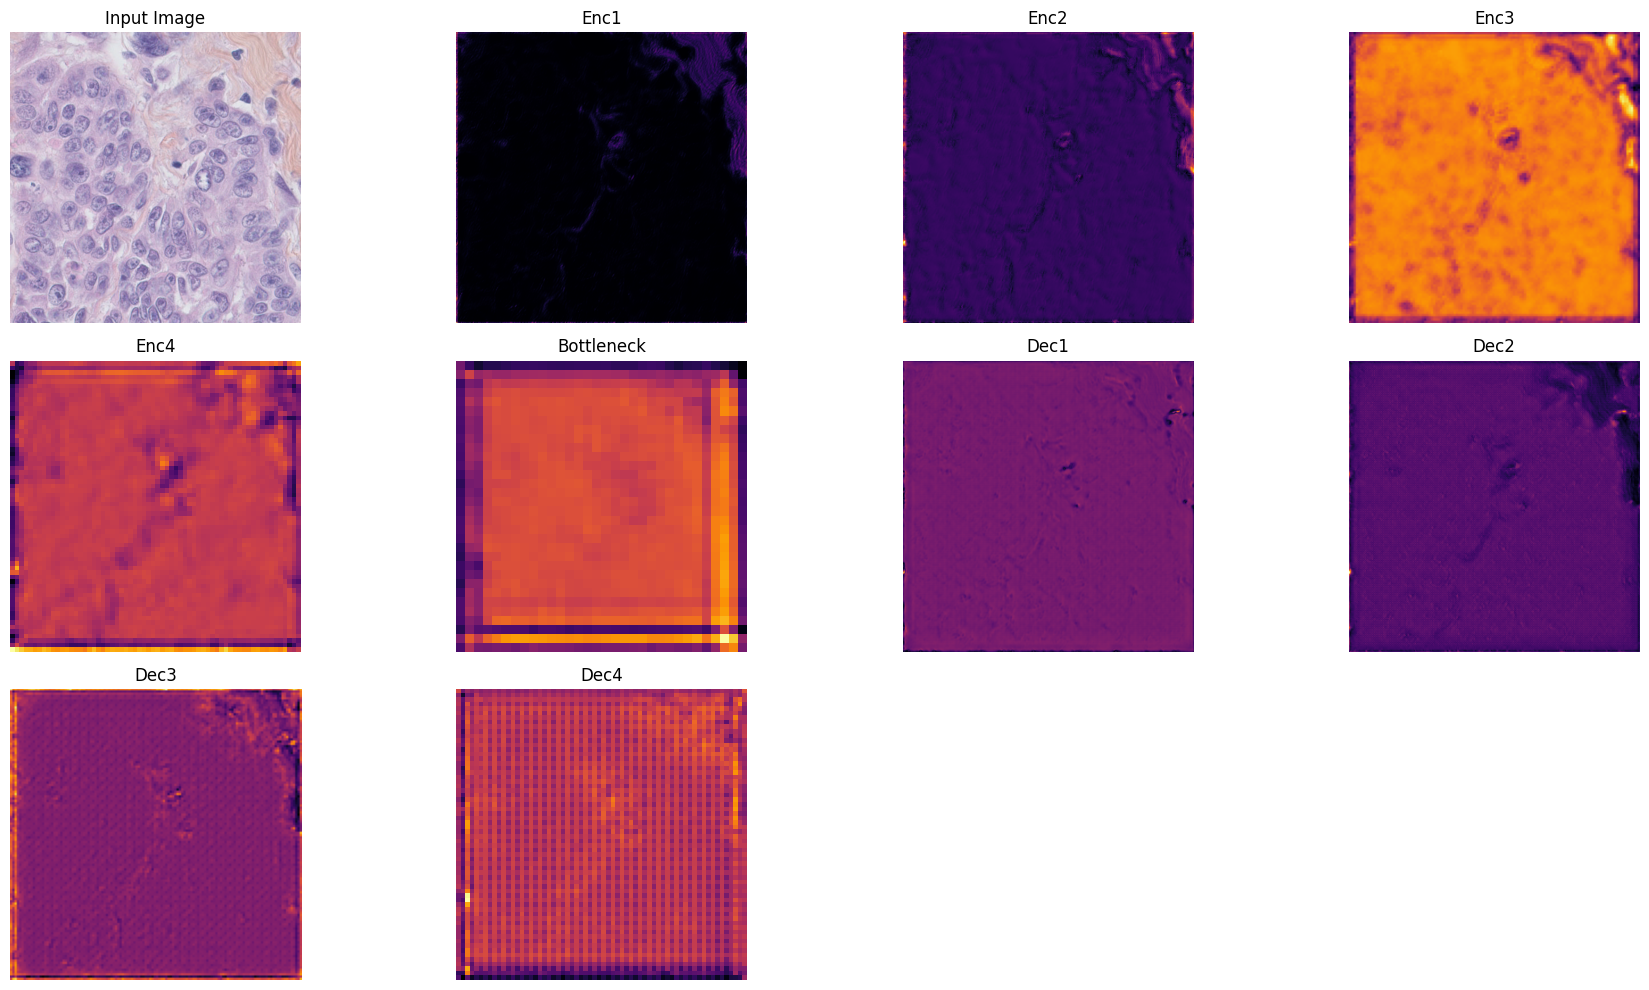

In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# Step 1: Load the model
model.load_state_dict(torch.load('best_unet_monu.pth'))
model.eval()

# Step 2: Load and preprocess the input image
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")

    preprocess = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    image_tensor = preprocess(image)
    image_tensor = image_tensor.unsqueeze(0)
    return image, image_tensor

input_image_path = '/kaggle/input/datasets/maitygouranga/brest-cancer-datasets/monuseg/Brest cancer/TNBC_without_split/Images/01_2.png'
original_image, input_tensor = load_image(input_image_path)
input_tensor = input_tensor.to('cuda')

# Define all target layers
# target_layers = {
#     "Enc1": model.enc1,
#     # "Enc2": model.enc2,
#     # "Enc3": model.enc3,
#     # "Enc4": model.enc4,
#     "Bottleneck": model.bottleneck,
#     "Dec1": model.dec1,
#     # "Dec2": model.dec2,
#     # "Dec3": model.dec3,
#     # "Dec4": model.dec4,
# }

# Define all target layers
target_layers = {
    "Enc1": model.e1,
    "Enc2": model.e2,
    "Enc3": model.e3,
    "Enc4": model.e4,
    "Bottleneck": model.bottleneck,
    "Dec1": model.d1,
    "Dec2": model.d2,
    "Dec3": model.d3,
    "Dec4": model.d4,
}

# Plot setup
plt.figure(figsize=(18, 10))

# Show input image
plt.subplot(3, 4, 1)
plt.imshow(original_image.resize((512, 512)))
plt.title("Input Image")
plt.axis('off')

plot_index = 2

# Loop through all layers
for layer_name, target_layer in target_layers.items():

    activation = []

    def get_activation(layer):
        def hook(model, input, output):
            activation.append(output)
        return hook

    hook = target_layer.register_forward_hook(get_activation(target_layer))

    with torch.no_grad():
        output = model(input_tensor)

    hook.remove()

    activation_map = activation[0]
    activation_map = activation_map.mean(dim=1, keepdim=True)
    activation_map = F.relu(activation_map)

    activation_map = (activation_map - activation_map.min()) / \
                     (activation_map.max() - activation_map.min() + 1e-8)

    activation_map = activation_map.squeeze().cpu().numpy()

    plt.subplot(3, 4, plot_index)
    plt.imshow(activation_map, cmap='inferno')
    plt.title(layer_name)
    plt.axis('off')

    plot_index += 1

plt.tight_layout()
plt.show()

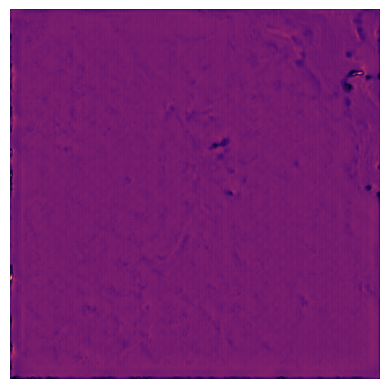

In [9]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# Step 1: Load the model (ensure it's defined as per your architecture)
model.load_state_dict(torch.load('best_unet_monu.pth'))
model.eval()

# Step 2: Load and preprocess the input image
def load_image(image_path):
    # Load the image
    image = Image.open(image_path).convert("RGB")  # Ensure it's RGB

    # Define the transformations
    preprocess = transforms.Compose([
        transforms.Resize((512, 512)),  # Resize to match model input
        transforms.ToTensor(),  # Convert to tensor
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Normalize
    ])

    # Apply transformations
    image_tensor = preprocess(image)
    image_tensor = image_tensor.unsqueeze(0)  # Add batch dimension
    return image_tensor

# Load your input image (replace with your actual image path)
input_image_path = '/kaggle/input/datasets/maitygouranga/brest-cancer-datasets/monuseg/Brest cancer/TNBC_without_split/Images/01_2.png'  # Specify the path to your image
input_tensor = load_image(input_image_path)
input_tensor = input_tensor.to('cuda')

# Step 3: Set up the hook and perform Grad-CAM
def get_activation(layer):
    def hook(model, input, output):
        activation.append(output)
    return hook

# Choose the target layer for Grad-CAM
target_layer = model.d1  # Modify this to your architecture

# Register the hook
activation = []
hook = target_layer.register_forward_hook(get_activation(target_layer))

# Forward pass through the model
with torch.no_grad():
    output = model(input_tensor)

# Unregister the hook
hook.remove()

# Now you can access the activation
activation_map = activation[0]  # Get the activation from the hook

# Assuming the output shape is [N, C, H, W]
# For visualization, we need to take the average across the channels
activation_map = activation_map.mean(dim=1, keepdim=True)  # Shape: [N, 1, H, W]
activation_map = F.relu(activation_map)  # ReLU activation

# Normalize the activation map for visualization
activation_map = (activation_map - activation_map.min()) / (activation_map.max() - activation_map.min())
activation_map = activation_map.squeeze().cpu().numpy()  # Convert to numpy for plotting

# Plot the activation map
plt.imshow(activation_map, cmap='inferno')  # or any other colormap
plt.axis('off')  # Turn off axis
#plt.colorbar()  # Show colorbar for reference
#plt.title('Grad-CAM Activation Map')
plt.show()

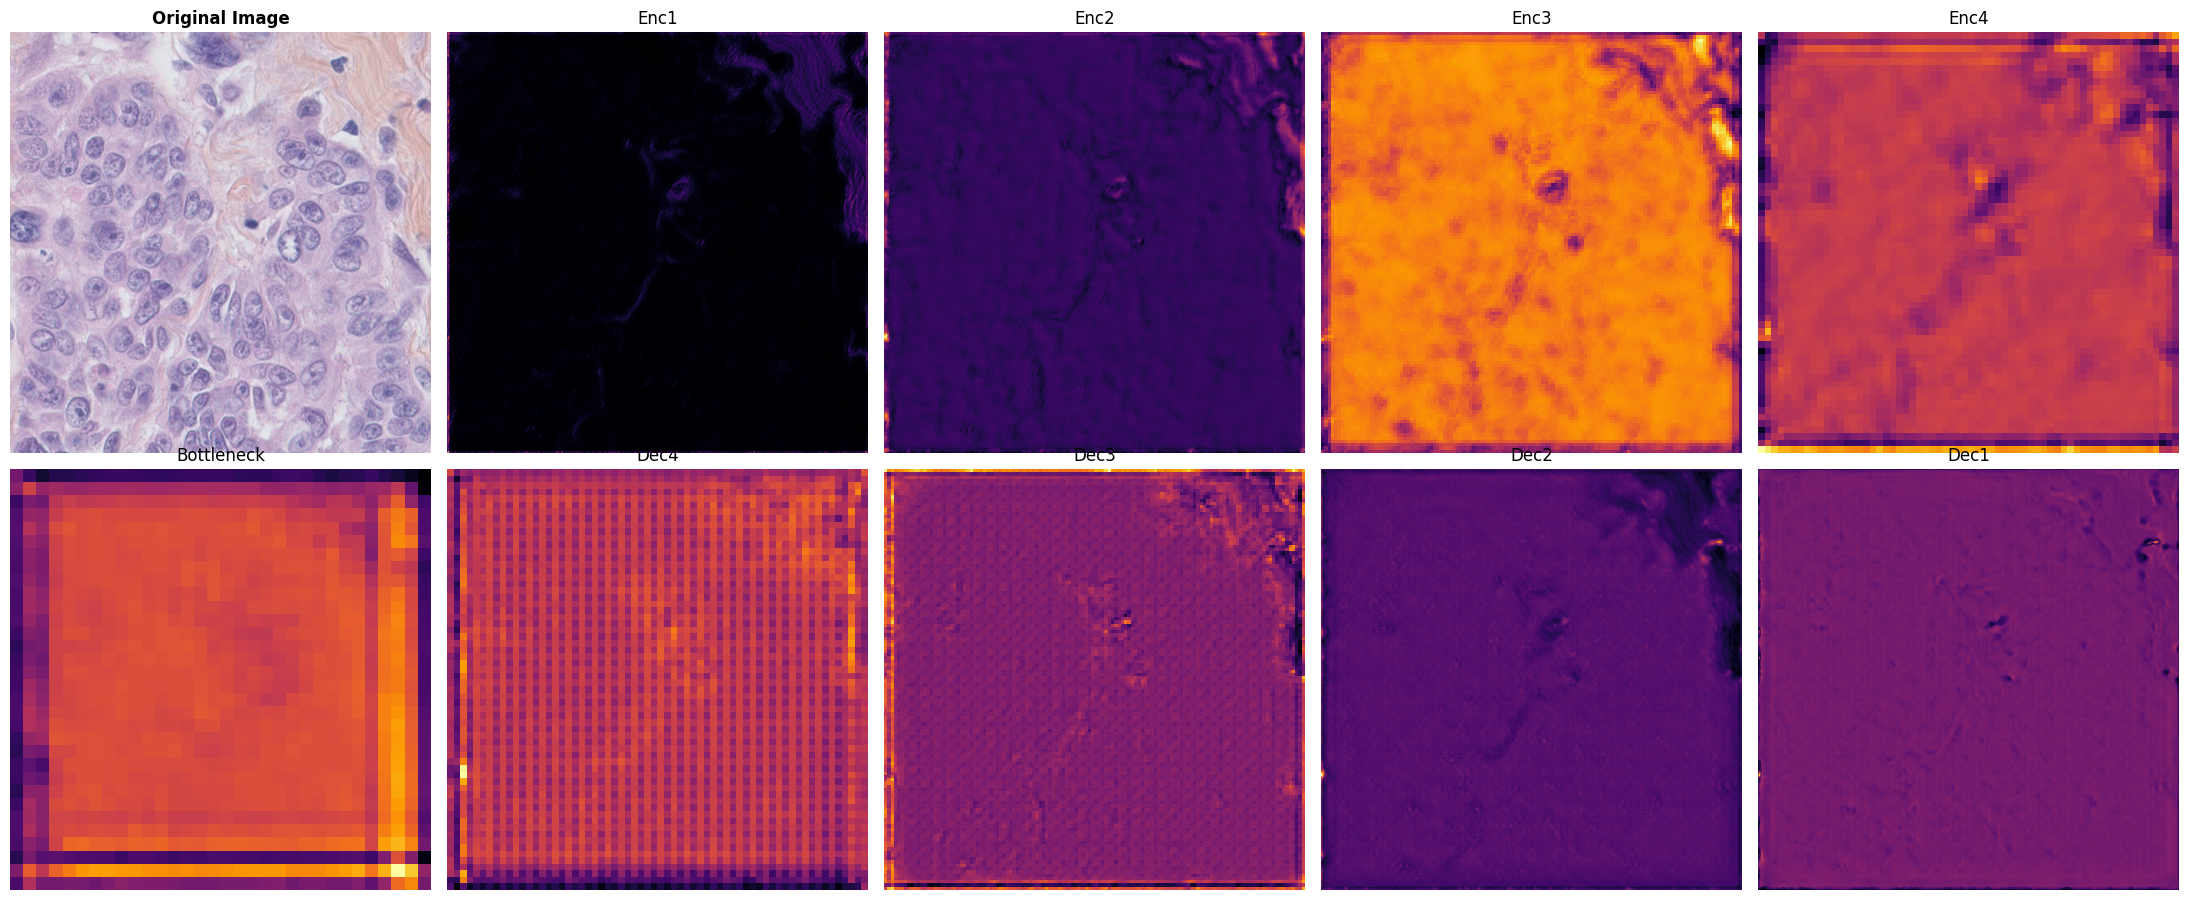

In [10]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import numpy as np

# Step 1: Load the model (ensure it's defined as per your architecture)
model.load_state_dict(torch.load('best_unet_monu.pth'))
model.eval()

# Step 2: Load and preprocess the input image
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    preprocess = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    image_tensor = preprocess(image)
    image_tensor = image_tensor.unsqueeze(0)
    return image, image_tensor # Returning both original PIL image and tensor

input_image_path = '/kaggle/input/datasets/maitygouranga/brest-cancer-datasets/monuseg/Brest cancer/TNBC_without_split/Images/01_2.png'
original_img, input_tensor = load_image(input_image_path)
input_tensor = input_tensor.to('cuda')

# Define all the target layers in a dictionary
target_layers = {
    "Enc1": model.e1,
    "Enc2": model.e2,
    "Enc3": model.e3,
    "Enc4": model.e4,
    "Bottleneck": model.bottleneck,
    "Dec1": model.d1,
    "Dec2": model.d2,
    "Dec3": model.d3,
    "Dec4": model.d4,
}

# Dictionary to store activations dynamically
activations = {}

# Step 3: Hook function creator that maps output to its specific layer name
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Register hooks for ALL layers in the dictionary
hooks = []
for name, layer in target_layers.items():
    hooks.append(layer.register_forward_hook(get_activation(name)))

# Forward pass through the model
with torch.no_grad():
    output = model(input_tensor)

# Clean up and remove all hooks immediately after the forward pass
for hook in hooks:
    hook.remove()

# Step 4: Setup a 2x5 grid layout (10 spots total)
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

# 1. Plot the Original Image in the first slot (resized to match dimensions)
resized_original = original_img.resize((512, 512))
axes[0].imshow(resized_original)
axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
axes[0].axis('off')

# 2. Loop through and plot the 9 layer activations in the remaining slots
for i, (name, act_map) in enumerate(activations.items()):
    # Average across channels (Shape: [1, 1, H, W])
    act_map = act_map.mean(dim=1, keepdim=True)
    act_map = F.relu(act_map)
    
    # Normalize the activation map
    min_val = act_map.min()
    max_val = act_map.max()
    if max_val > min_val:
        act_map = (act_map - min_val) / (max_val - min_val)
        
    act_map = act_map.squeeze().cpu().numpy()
    
    # Target axes[i + 1] because index 0 is occupied by the original image
    ax = axes[i + 1]
    ax.imshow(act_map, cmap='inferno')
    ax.set_title(name, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()